In [1]:
#!module load cuda11/11.8
!nvidia-smi

Wed Oct 22 14:13:04 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100S-PCIE-32GB          On  |   00000000:81:00.0 Off |                    0 |
| N/A   45C    P0             85W /  250W |     448MiB /  32768MiB |     70%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA version PyTorch built with:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU device name:", torch.cuda.get_device_name(0))
else:
    print("CUDA not available")


import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import numpy as np
import os
print(os.environ.get('CONDA_DEFAULT_ENV'))

from tqdm import tqdm, trange

import sys
sys.path.append('../utilities')

import to_utils
import models_torch

PyTorch version: 2.5.1
CUDA version PyTorch built with: 12.1
CUDA available: True
GPU device name: Tesla V100S-PCIE-32GB
None


Load the data. If the following errors out, please check that you have downloaded the TO datasets. Note that this notebook loads the entire data into memory. If memory limited, this notebook may have to be modified. 

In [3]:
P, N_real, N_procedural, N_rejected = to_utils.load_data("../TO_Datasets/")

/home/u26/emcdugald/TO_Gan/Paper_Experiments/../utilities/to_utils.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  all_images = torch.load(os.path.join(directory, "all_

You can select to use the procedurally-generated negative data or rejection-sampled negative data.

In [4]:
#select synthetic or rejection sampled negative data to add to the few real negatives

N = torch.cat((N_real, N_procedural), 0)
# N = torch.cat((N_real, N_rejected), 0)

We'll make sure all the positive data and negative data are, in fact, positive and negative respectively:

In [5]:
validity, _ = to_utils.eval_batch_validity(N.detach().numpy())
assert np.all(validity == False)

validity, _ = to_utils.eval_batch_validity(P.detach().numpy())
assert np.all(validity == True)


Perform data augmentations on the data (optional, but used in the paper):

In [6]:
#use all four rotations and two flips to augment the data 

P = to_utils.augment_all(P)
N = to_utils.augment_all(N)

Preprocess:

In [7]:
P = P.unsqueeze(1)
N = N.unsqueeze(1)
P = P.type(torch.float32)/255*2-1
N = N.type(torch.float32)/255*2-1

P = P[torch.randperm(P.shape[0])]
N = N[torch.randperm(N.shape[0])]

Select a train step function (GAN, GAN-DO or GAN-MDD):

In [8]:
from models_torch import GAN_step_MDD, GAN_step_DO, GAN_step_vanilla

# train_step_fn = GAN_step_vanilla
# train_step_fn = GAN_step_DO
train_step_fn = GAN_step_MDD

We define some hyperparameters and create the networks:

In [9]:
num_epochs = 1
lr = 0.0002
beta1 = 0.5
image_size = 64
batch_size = 128
nz = 100  # Size of the latent vector
ngf = 64  # Size of feature maps in the generator
ndf = 64  # Size of feature maps in the discriminator

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:",device)
    
netG = to_utils.Generator(nz, ngf).to(device)

if train_step_fn == GAN_step_MDD:
    netD = to_utils.Discriminator(ndf, 3).to(device)
else:
    netD = to_utils.Discriminator(ndf, 1).to(device)

!nvidia-smi


device: cuda
Wed Oct 22 14:14:56 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100S-PCIE-32GB          On  |   00000000:81:00.0 Off |                    0 |
| N/A   45C    P0             75W /  250W |     796MiB /  32768MiB |     64%      Default |
|                                         |                        |                  N/A |
+----------------------------------

Time to train the model!

In [10]:
from models_torch import train, ReusableDataLoader
from torch.utils.data import TensorDataset

num_steps = num_epochs*len(P)//batch_size

D_opt = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
G_opt = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

def check_refill_pool(pool, length, batch_size):
    if length<batch_size:
        raise Exception("dataset is smaller than batch size!")
    while len(pool)<batch_size:
        remset = set(range(length))-set(pool)
        pool = pool + list(remset)
    return pool

P_loader = ReusableDataLoader(TensorDataset(P), batch_size)
N_loader = ReusableDataLoader(TensorDataset(N), batch_size)

netD, netG, _ = train(netD, netG, None, D_opt, G_opt, None, P_loader, N_loader, num_steps, batch_size, nz, train_step_fn, device, 1, 0)

100%|██████████| 2027/2027 [03:11<00:00, 10.56it/s, L_D_real=0.9933, L_D_neg=1.8249, L_D_fake=0.0039, L_G=0.7919]


Great! Now lets evaluate 1000 batch of 128 topologies:

In [11]:
all_valid, all_areas, all_diversity = to_utils.evaluate_n_batches(netG, device, nz, 1000, 128)
print("Mean invalidity rate (%):", (1-np.mean(all_valid))*100)
print("Mean violation magnitude (%):", np.mean(all_areas)/64/64*100)
print("Mean diversity:", np.mean(all_diversity))

100%|██████████| 1000/1000 [00:19<00:00, 51.72it/s]

Mean invalidity rate (%): 81.2359375
Mean violation magnitude (%): 1.571413230895996
Mean diversity: 15.377445475682478


We'll plot a few generated images and label them with their validity:

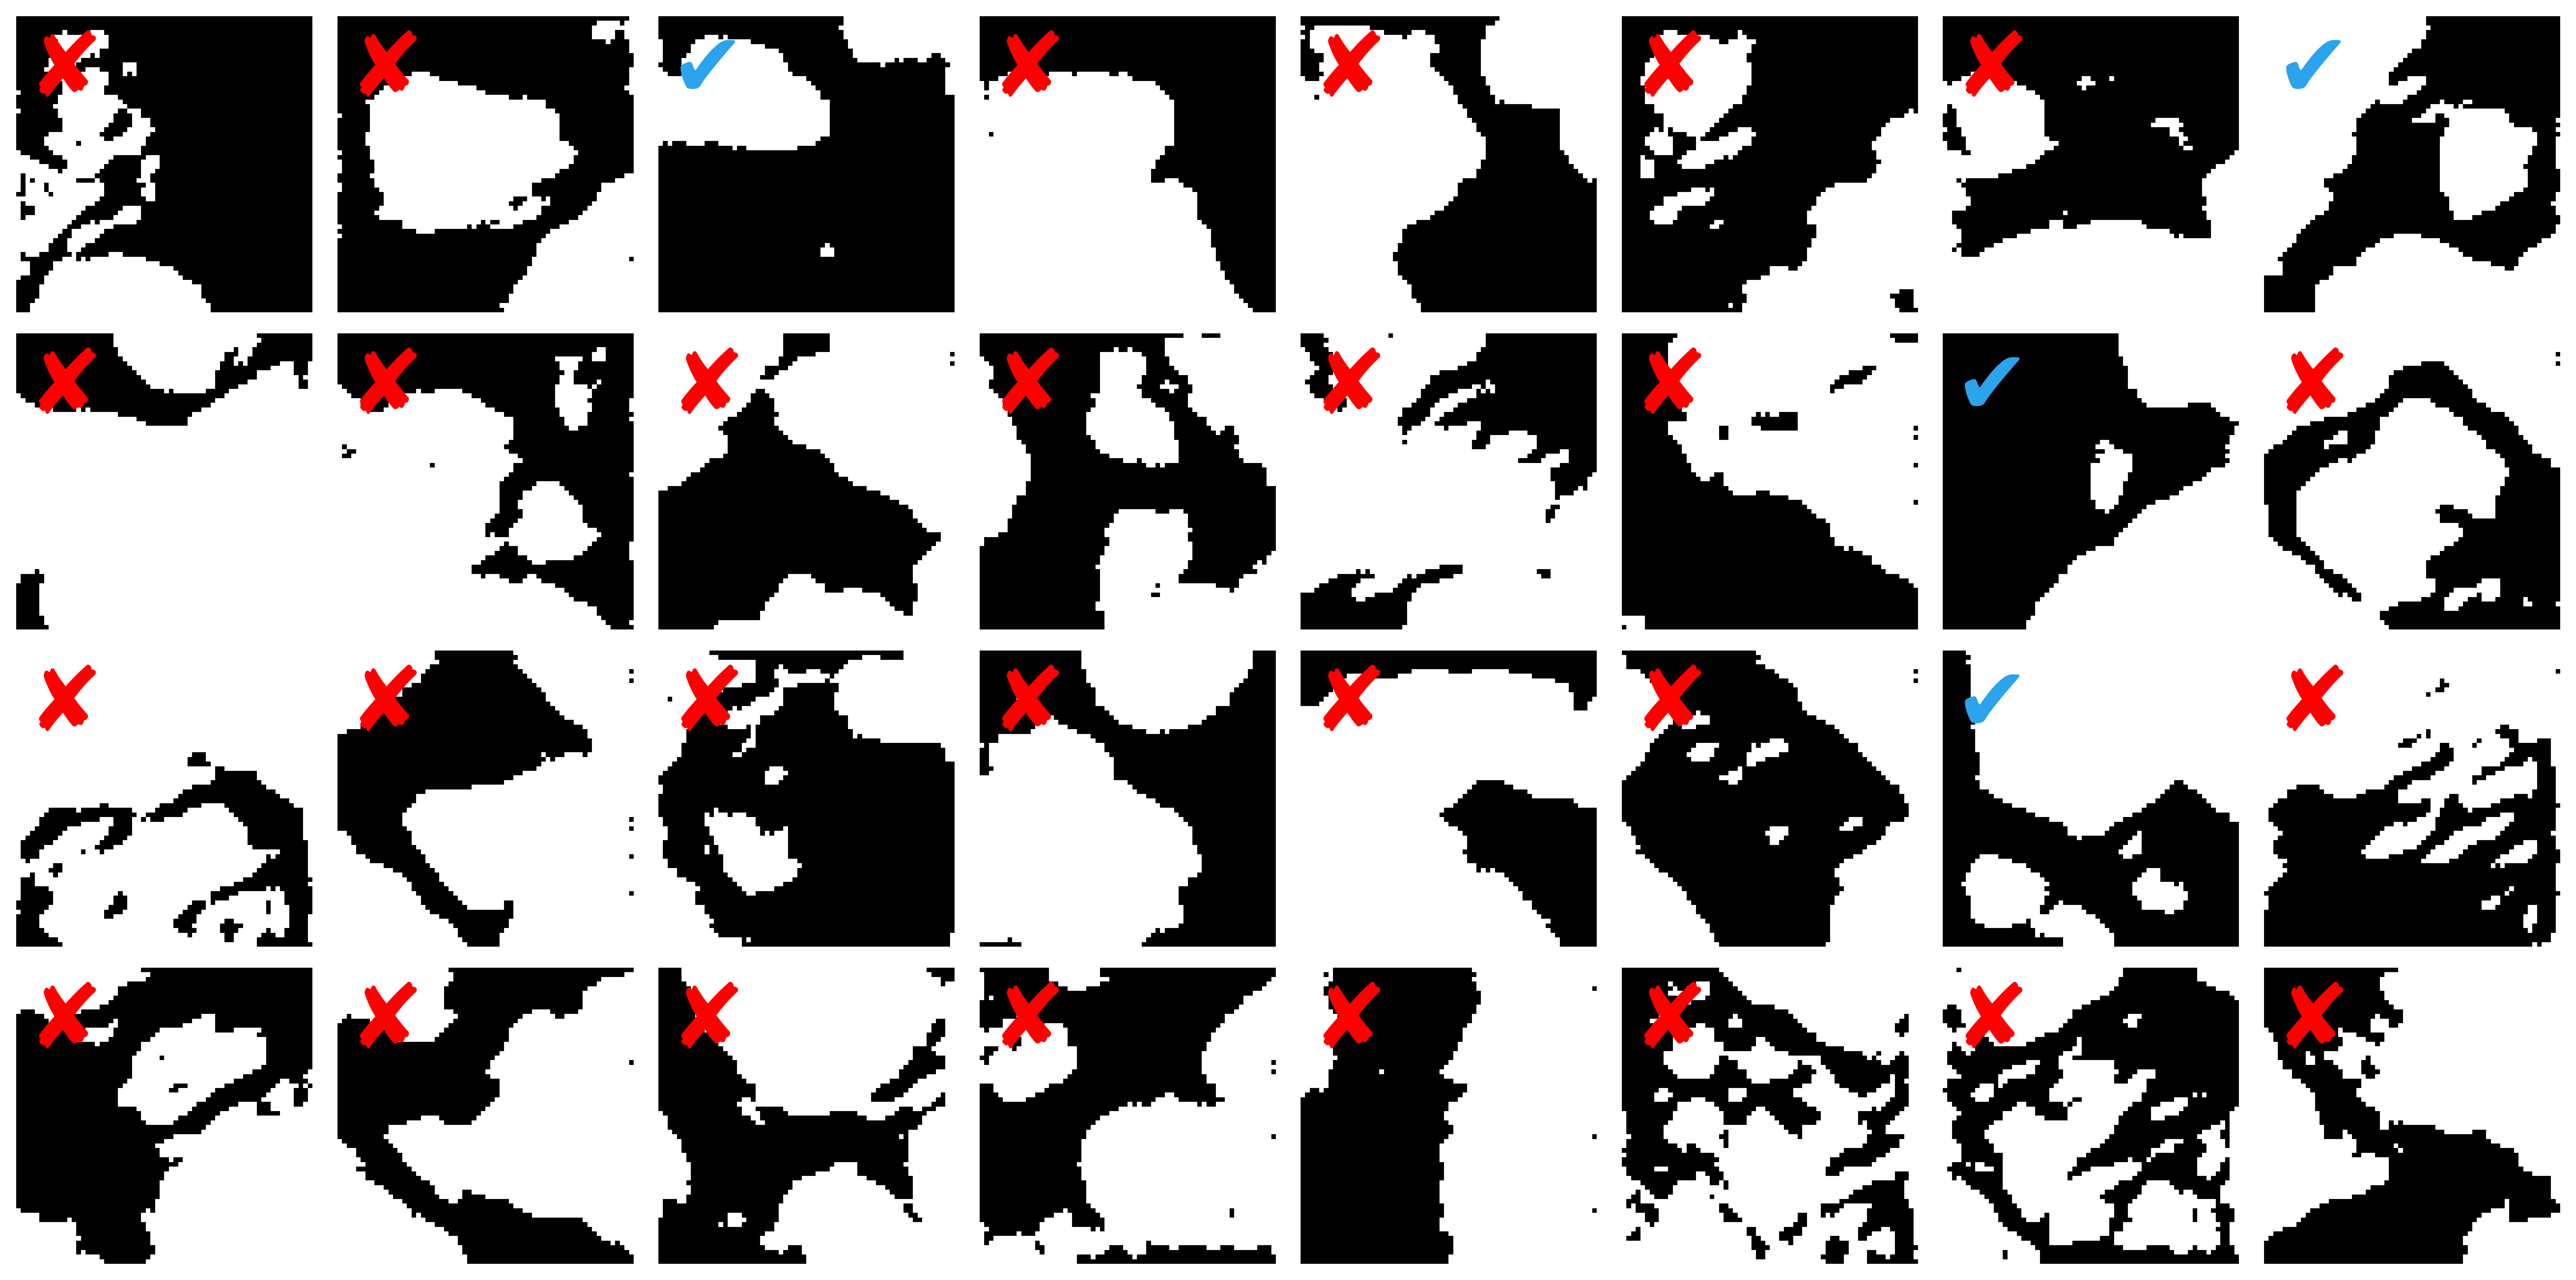

In [12]:
fake = netG(torch.randn(batch_size, nz, 1, 1, device=device)).detach().cpu()
fake = (fake>0)*255
samples=fake.cpu().numpy()[:,0,:,:]
validity, _ = to_utils.eval_batch_validity(samples)
fig, ax = plt.subplots(4, 8, figsize=(16, 8), dpi=400)
for i in range(4):
    for j in range(8):
        idx = i*8+j
        ax[i, j].imshow(samples[idx], cmap='gray')
        ax[i, j].axis('off')
        if validity[idx] == 1:  # Valid sample
            ax[i, j].text(2, 2, '✔', color='#2BA3ED', fontsize=40, 
                        ha='left', va='top', fontweight='bold')
        else:  # Invalid sample
            ax[i, j].text(2, 2, '✘', color='red', fontsize=40, 
                        ha='left', va='top', fontweight='bold')
fig.tight_layout()